# 📊 Customer Segmentation and Profiling using Machine Learning

## Capstone Project 2

### 🎯 Objective

The objective of this project is to segment customers into different groups using clustering techniques. These customer segments can help businesses design personalized marketing campaigns, improve customer satisfaction, and increase revenue.

### Machine Learning Technique

- Unsupervised Learning
- K-Means Clustering

### Libraries Used

- Pandas
- NumPy
- Matplotlib
- Scikit-learn

# 📦 Import Required Libraries

Import all the necessary Python libraries required for data analysis, visualization, and clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


# 📂 Load Dataset

Load the customer dataset into a Pandas DataFrame.

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# 🔍 Exploratory Data Analysis

Understand the structure of the dataset and identify patterns before clustering.

In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [10]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


# 📊 Step 5: Data Visualization

Visualizing customer data helps identify patterns, trends, and relationships before applying clustering algorithms.

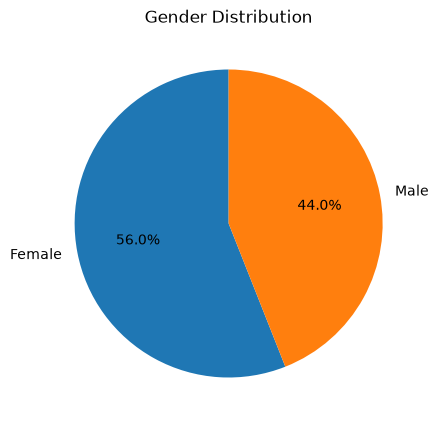

In [11]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6,5))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Gender Distribution")
plt.show()

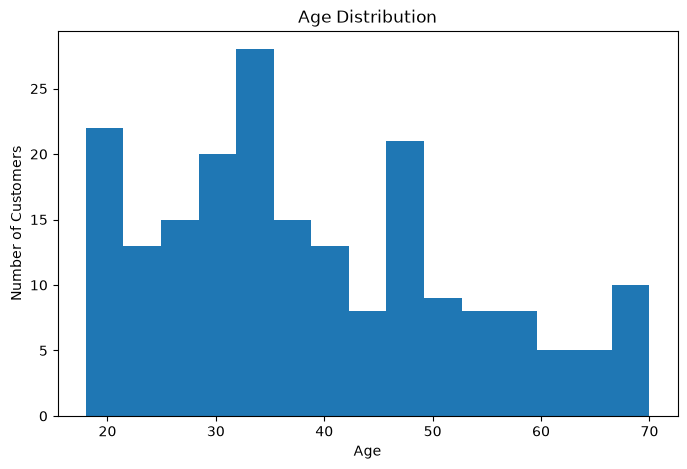

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

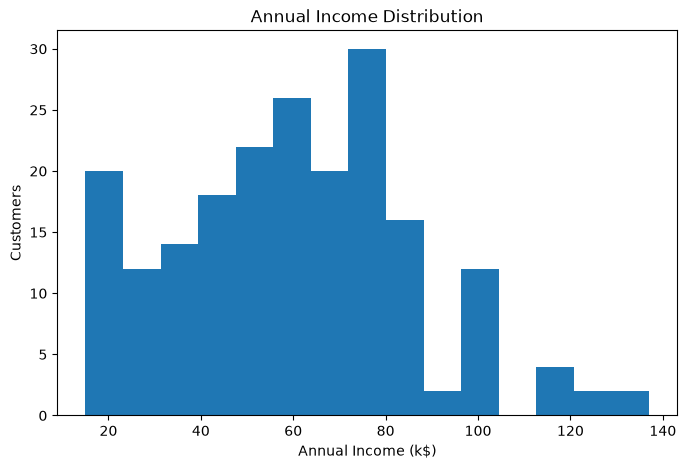

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["Annual Income (k$)"], bins=15)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Customers")

plt.show()

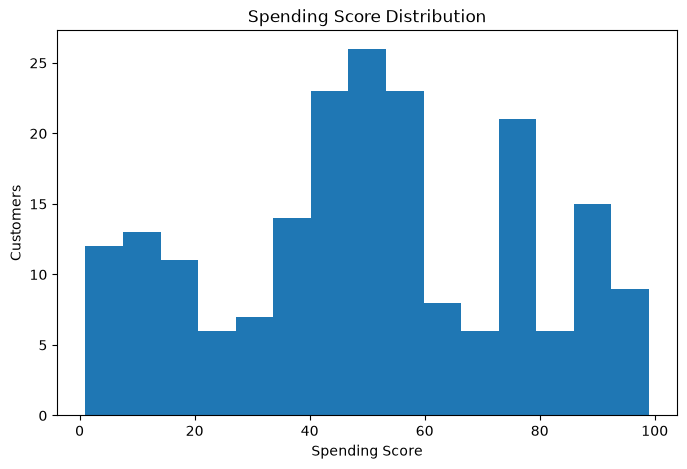

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["Spending Score (1-100)"], bins=15)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Customers")

plt.show()

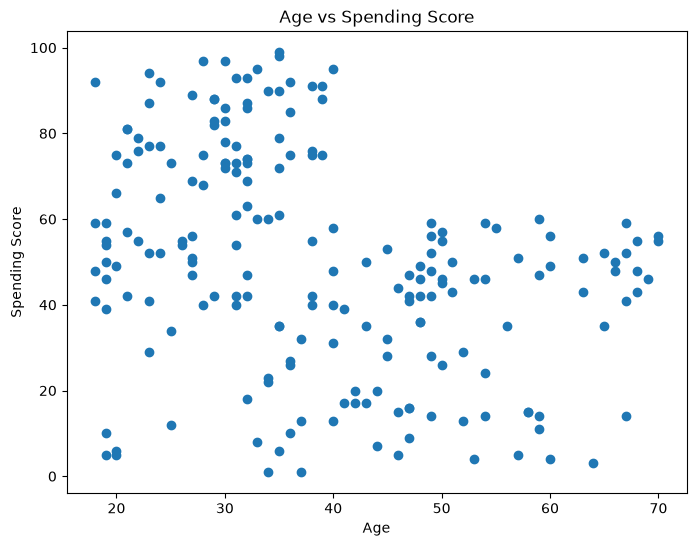

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Age"],
    df["Spending Score (1-100)"]
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")

plt.show()

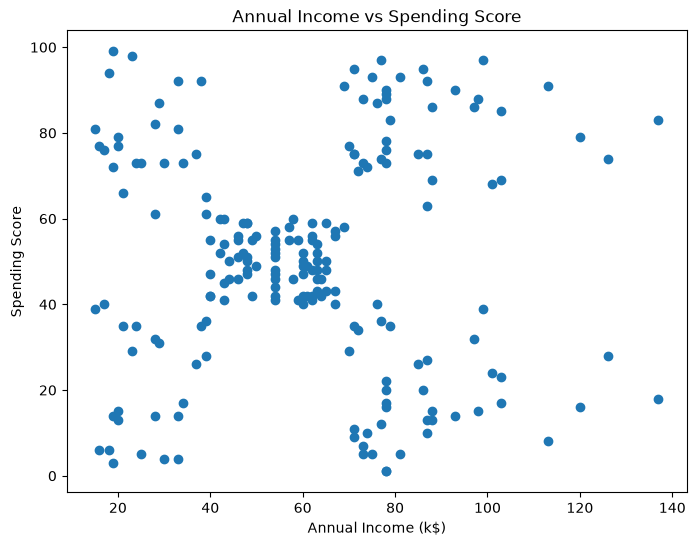

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

# 📈 Step 6: Feature Selection

For customer segmentation, we will use **Annual Income** and **Spending Score** as the main features for clustering because they clearly represent purchasing behavior.

In [17]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [18]:
X.shape

(200, 2)

# ⚙️ Step 7: Feature Scaling

Feature scaling ensures that all features contribute equally during clustering. We use **StandardScaler** to standardize the data before applying the K-Means algorithm.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("✅ Feature Scaling Completed Successfully!")

✅ Feature Scaling Completed Successfully!


In [20]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

# 📉 Step 8: Elbow Method

The Elbow Method helps determine the optimal number of clusters (K) by plotting the Within-Cluster Sum of Squares (WCSS) against different values of K.

In [21]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("✅ WCSS Calculated Successfully!")

✅ WCSS Calculated Successfully!


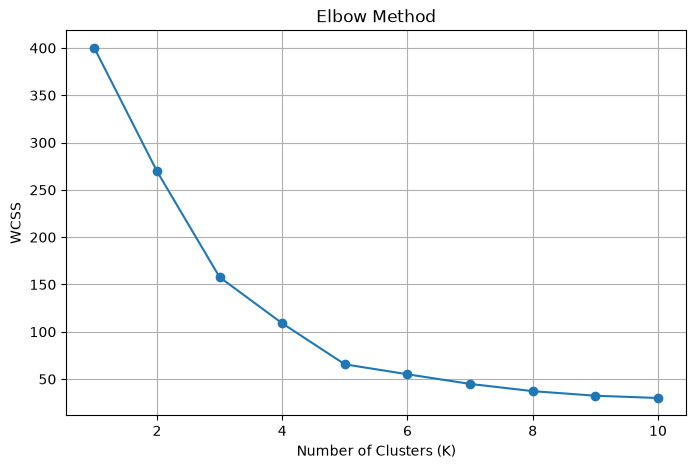

In [22]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

# 🤖 Step 9: Apply K-Means Clustering

Based on the Elbow Method, we apply the K-Means algorithm to divide customers into meaningful groups.

In [23]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("✅ K-Means Clustering Completed Successfully!")

✅ K-Means Clustering Completed Successfully!


In [24]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


# 🎨 Step 10: Customer Segmentation Visualization

Visualize the customer clusters created using the K-Means algorithm. Each color represents a different customer segment, while the black 'X' markers indicate the cluster centroids.

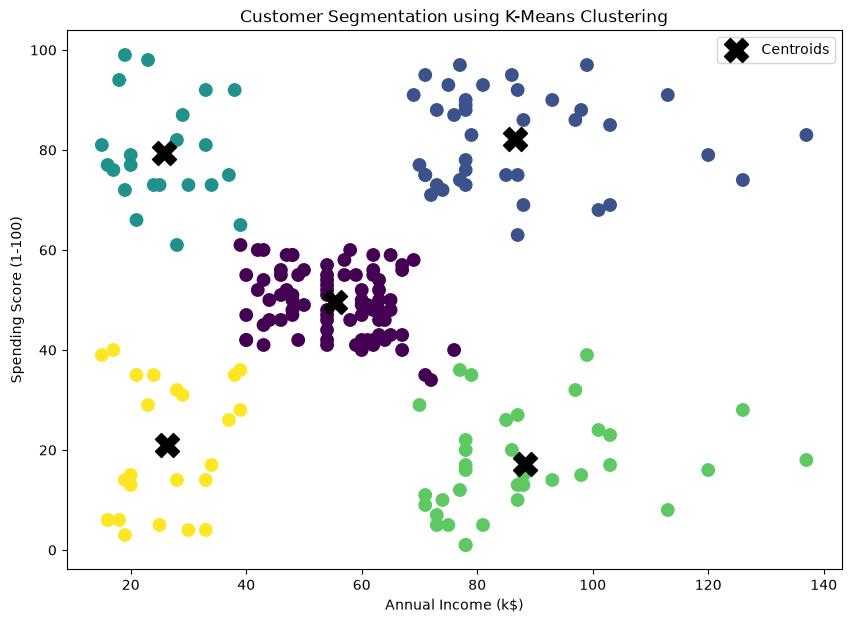

In [25]:
plt.figure(figsize=(10,7))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=80
)

# Plot cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=300,
    c="black",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

# 👥 Step 11: Customer Profiling

Analyze each customer cluster by calculating the average age, annual income, and spending score to understand customer behavior.

In [26]:
cluster_profile = df.groupby("Cluster").agg({
    "Age":"mean",
    "Annual Income (k$)":"mean",
    "Spending Score (1-100)":"mean"
}).round(2)

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


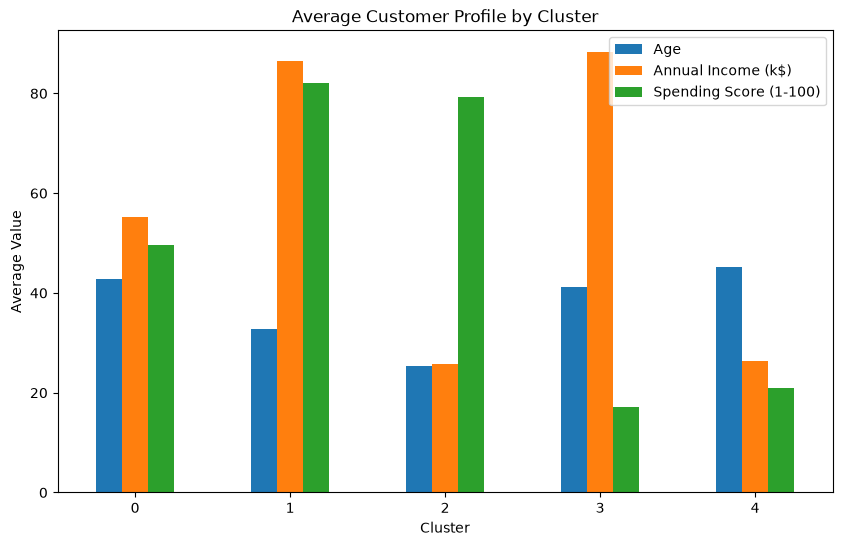

In [27]:
cluster_profile.plot(kind="bar", figsize=(10,6))

plt.title("Average Customer Profile by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.show()

# 🎯 Step 12: Targeting Strategy

Based on customer segmentation, different marketing strategies can be designed for each customer group.

### Suggested Strategies

- High Income + High Spending → Premium Membership & Exclusive Offers
- High Income + Low Spending → Personalized Promotions
- Low Income + High Spending → Discount Campaigns & Loyalty Rewards
- Low Income + Low Spending → Budget-Friendly Products
- Medium Income + Medium Spending → Cross-selling & Upselling

# 💼 Step 13: Business Recommendations

### Recommendations

- Focus marketing efforts on high-value customers.
- Improve engagement with low-spending customers.
- Design personalized offers for each customer segment.
- Launch loyalty programs for premium customers.
- Use customer segmentation for targeted marketing campaigns.
- Continuously monitor customer behavior to improve retention.

# 🏁 Conclusion

This project successfully segmented customers into meaningful groups using the K-Means Clustering algorithm.

### Workflow Completed

- Data Collection
- Data Exploration
- Data Visualization
- Feature Scaling
- Elbow Method
- K-Means Clustering
- Customer Profiling
- Targeting Strategy
- Business Recommendations

The insights generated from customer segmentation can help businesses improve marketing efficiency, customer satisfaction, and overall business growth through data-driven decision-making.

# 💾 Save Clustered Dataset

Save the final dataset with customer cluster labels for future analysis and business applications.

In [28]:
df.to_csv("customer_segmentation.csv", index=False)

print("✅ Customer segmentation dataset saved successfully!")

✅ Customer segmentation dataset saved successfully!
